In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/heart-disease/dataset.csv


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error
import joblib as jb

In [3]:
train=pd.read_csv("/kaggle/input/heart-disease/dataset.csv")

In [4]:
train.head()

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289,0,0,172,0,0.0,1,0
1,49,0,3,160,180,0,0,156,0,1.0,2,1
2,37,1,2,130,283,0,1,98,0,0.0,1,0
3,48,0,4,138,214,0,0,108,1,1.5,2,1
4,54,1,3,150,195,0,0,122,0,0.0,1,0


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1190 entries, 0 to 1189
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  1190 non-null   int64  
 1   sex                  1190 non-null   int64  
 2   chest pain type      1190 non-null   int64  
 3   resting bp s         1190 non-null   int64  
 4   cholesterol          1190 non-null   int64  
 5   fasting blood sugar  1190 non-null   int64  
 6   resting ecg          1190 non-null   int64  
 7   max heart rate       1190 non-null   int64  
 8   exercise angina      1190 non-null   int64  
 9   oldpeak              1190 non-null   float64
 10  ST slope             1190 non-null   int64  
 11  target               1190 non-null   int64  
dtypes: float64(1), int64(11)
memory usage: 111.7 KB


In [6]:
x=train.drop(columns=["target"])
y=train["target"]

In [7]:
for col in (train.columns):
    print(col,train[col].nunique())
    print(train[col].describe())
    print("\n")

age 50
count    1190.000000
mean       53.720168
std         9.358203
min        28.000000
25%        47.000000
50%        54.000000
75%        60.000000
max        77.000000
Name: age, dtype: float64


sex 2
count    1190.000000
mean        0.763866
std         0.424884
min         0.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: sex, dtype: float64


chest pain type 4
count    1190.000000
mean        3.232773
std         0.935480
min         1.000000
25%         3.000000
50%         4.000000
75%         4.000000
max         4.000000
Name: chest pain type, dtype: float64


resting bp s 67
count    1190.000000
mean      132.153782
std        18.368823
min         0.000000
25%       120.000000
50%       130.000000
75%       140.000000
max       200.000000
Name: resting bp s, dtype: float64


cholesterol 222
count    1190.000000
mean      210.363866
std       101.420489
min         0.000000
25%       188.000000
50%       229.000000
75%   

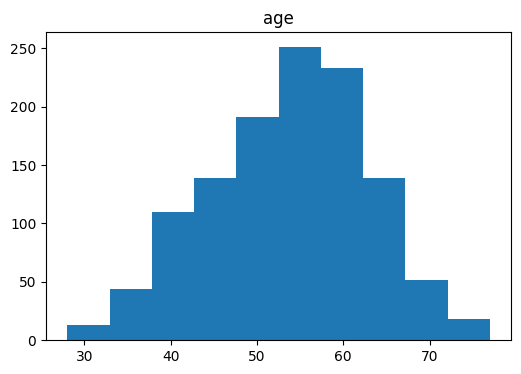

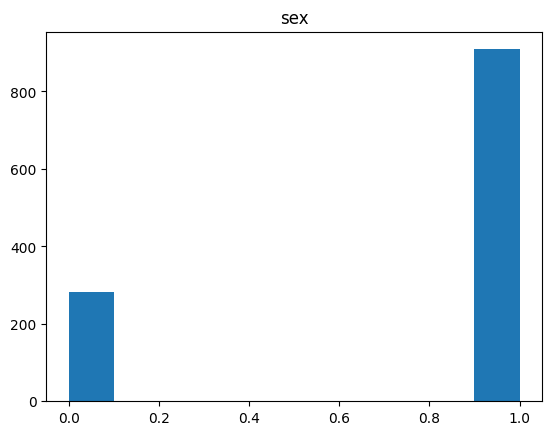

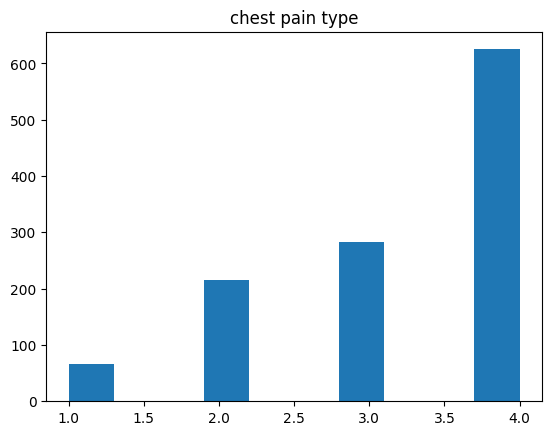

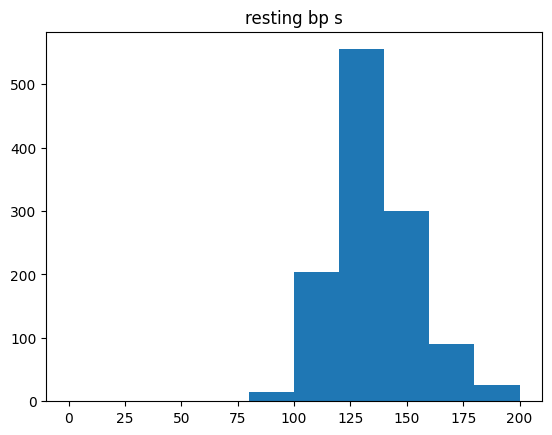

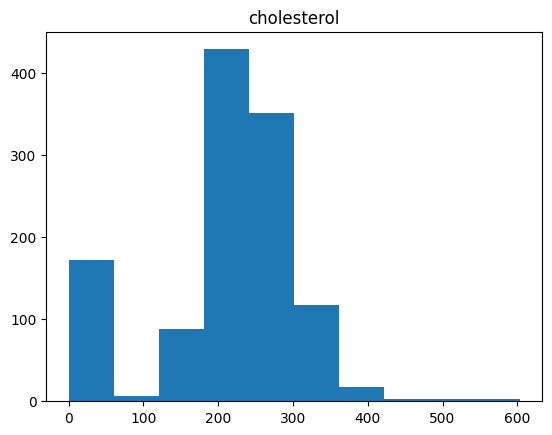

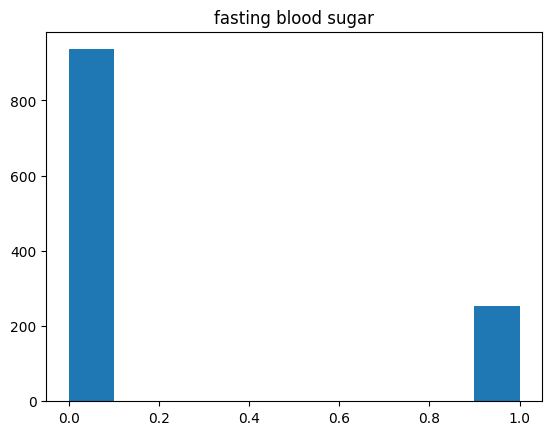

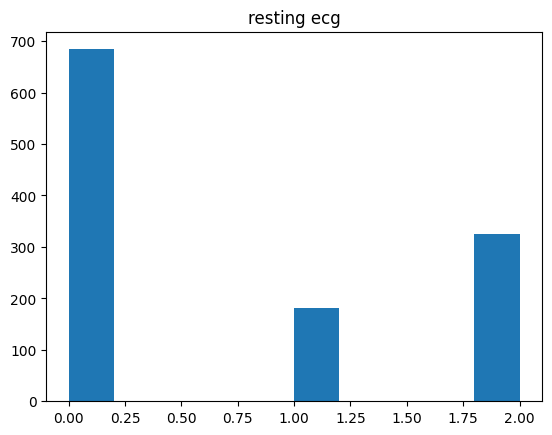

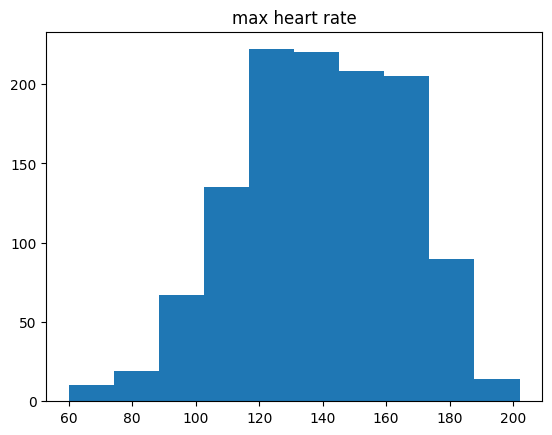

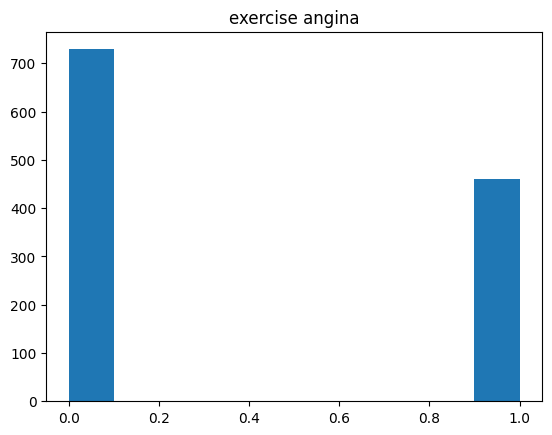

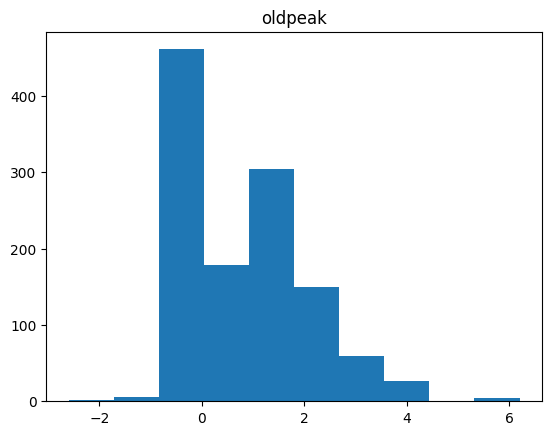

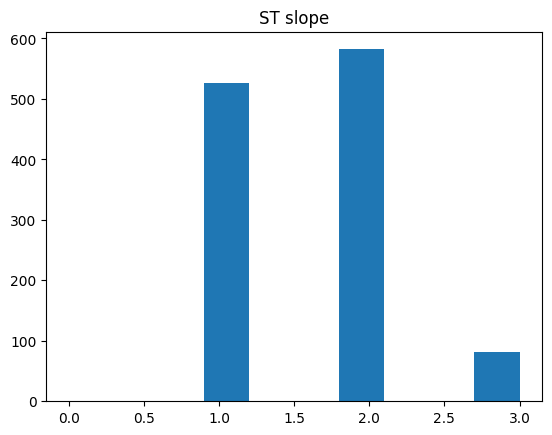

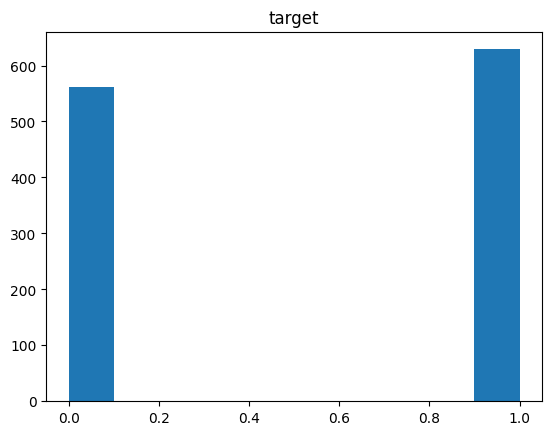

In [8]:
plt.figure(figsize=(6,4))
for col in (train.columns):
    
    plt.hist(train[col])
    plt.title(f'{col}')
    plt.show()

In [9]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)

In [10]:
x_train.head()

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope
1005,63,1,4,130,330,1,2,132,1,1.8,1
224,33,1,3,120,298,0,0,185,0,0.0,1
798,56,0,4,134,409,0,2,150,1,1.9,2
816,77,1,4,125,304,0,2,162,1,0.0,1
427,56,1,2,126,166,0,1,140,0,0.0,1


In [11]:
pipeline=Pipeline(steps={
    ("linear",LogisticRegression())
})

In [12]:
pipeline.fit(x_train,y_train)

InvalidParameterError: The 'steps' parameter of Pipeline must be an instance of 'list'. Got {('linear', LogisticRegression())} instead.

In [ ]:
y_pred=pipeline.predict(x_test)

In [ ]:
mae=mean_absolute_error(y_test,y_pred)

In [ ]:
print(mae)

In [ ]:
jb.dump(pipeline,"heart_pipeline.joblib")